In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

Data Loading and Cleaning,
Filter out non-physical zeros to prevent mathematical errors

In [2]:
df = pd.read_csv("Detector Data Germany.csv")
df = df[(df['Density (veh/km)'] > 0) & (df['Speed (Km/h)'] > 0)]

k = df['Density (veh/km)'].values
v = df['Speed (Km/h)'].values
q = df['Flow (veh/h)'].values

Empirical Data Extraction (Directly from Raw Data)

In [3]:


# Find the exact row where Flow (q) is at its absolute maximum
max_flow_row = df.loc[df['Flow (veh/h)'].idxmax()]

empirical_q_max = max_flow_row['Flow (veh/h)']
empirical_v_c = max_flow_row['Speed (Km/h)']
empirical_k_c = max_flow_row['Density (veh/km)']

# Find the absolute maximum observed speed (Free Flow Speed proxy)
empirical_v_f = df['Speed (Km/h)'].max()

# Find the absolute maximum observed density (Jam Density proxy)
empirical_k_j = df['Density (veh/km)'].max()

# Print the results to compare against the macroscopic models
print("Visually Observed (Empirical) Traffic Parameters ")
print(f"Observed Maximum Flow (Capacity, q_max): {empirical_q_max:.2f} veh/h")
print(f"Speed at Maximum Flow (Critical Speed, v_c): {empirical_v_c:.2f} km/h")
print(f"Density at Maximum Flow (Critical Density, k_c): {empirical_k_c:.2f} veh/km")
print(f"Highest Observed Speed (Free Flow Speed, v_f): {empirical_v_f:.2f} km/h")
print(f"Highest Observed Density (Jam Density, k_j): {empirical_k_j:.2f} veh/km")

Visually Observed (Empirical) Traffic Parameters 
Observed Maximum Flow (Capacity, q_max): 2380.00 veh/h
Speed at Maximum Flow (Critical Speed, v_c): 87.30 km/h
Density at Maximum Flow (Critical Density, k_c): 27.26 veh/km
Highest Observed Speed (Free Flow Speed, v_f): 146.40 km/h
Highest Observed Density (Jam Density, k_j): 85.71 veh/km


 Model Fitting (Speed vs Density)

In [4]:
# A. Greenshields Model (Linear)
m_g, c_g = np.polyfit(k, v, 1)
v_f_g = c_g
k_j_g = -c_g / m_g  # Extracting Greenshields Jam Density

# B. Greenberg Model (Logarithmic)
m_gb, c_gb = np.polyfit(np.log(k), v, 1)
c_val = -m_gb
k_j_gb = np.exp(c_gb / c_val)  # Extracting Greenberg Jam Density

# C. Underwood Model (Exponential)
m_u, c_u = np.polyfit(k, np.log(v), 1)
v_f_u = np.exp(c_u)
k_m_u = -1 / m_u


Calculating R^2 for ALL THREE Fundamental Diagrams 

In [5]:
v_pred_g = v_f_g * (1 - k / k_j_g)                 
q_pred_g_k = k * v_pred_g                          
q_pred_g_v = v * (k_j_g * (1 - v / v_f_g))         

v_pred_gb = c_val * np.log(k_j_gb / k)
q_pred_gb_k = k * v_pred_gb
q_pred_gb_v = v * (k_j_gb * np.exp(-v / c_val))

v_pred_u = v_f_u * np.exp(-k / k_m_u)
q_pred_u_k = k * v_pred_u
q_pred_u_v = v * (-k_m_u * np.log(v / v_f_u))


In [6]:
print(f"Mathematical R^2 Fit")
print(f"Greenshields -> v-k: {r2_score(v, v_pred_g):.4f} | q-k: {r2_score(q, q_pred_g_k):.4f} | q-v: {r2_score(q, q_pred_g_v):.4f}")
print(f"Greenberg    -> v-k: {r2_score(v, v_pred_gb):.4f} | q-k: {r2_score(q, q_pred_gb_k):.4f} | q-v: {r2_score(q, q_pred_gb_v):.4f}")
print(f"Underwood    -> v-k: {r2_score(v, v_pred_u):.4f} | q-k: {r2_score(q, q_pred_u_k):.4f} | q-v: {r2_score(q, q_pred_u_v):.4f}")

Mathematical R^2 Fit
Greenshields -> v-k: 0.7263 | q-k: -1.5158 | q-v: -1.0306
Greenberg    -> v-k: 0.7993 | q-k: 0.1522 | q-v: 0.2854
Underwood    -> v-k: 0.8046 | q-k: 0.2461 | q-v: 0.2295


Since Underwwod is the best fit

In [7]:
v_c_u = v_f_u / np.exp(1)  # Critical Speed
q_c_u = v_c_u * k_m_u      # Capacity

Modelled Parameters

In [8]:
print(f"\nDerived Traffic Parameters")
print(f"Greenshields Jam Density (kj): {k_j_g:.2f} veh/km")
print(f"Greenberg Jam Density (kj):    {k_j_gb:.2f} veh/km")
print(f"Underwood Free Flow Speed (vf):{v_f_u:.2f} km/h")
print(f"Underwood Critical Density (kc):{k_m_u:.2f} veh/km")
print(f"Underwood Critical Speed (vc): {v_c_u:.2f} km/h")
print(f"Underwood Capacity (Qc):       {q_c_u:.2f} veh/h")


Derived Traffic Parameters
Greenshields Jam Density (kj): 54.41 veh/km
Greenberg Jam Density (kj):    71.18 veh/km
Underwood Free Flow Speed (vf):168.39 km/h
Underwood Critical Density (kc):22.45 veh/km
Underwood Critical Speed (vc): 61.95 km/h
Underwood Capacity (Qc):       1390.67 veh/h


Plotting evrything

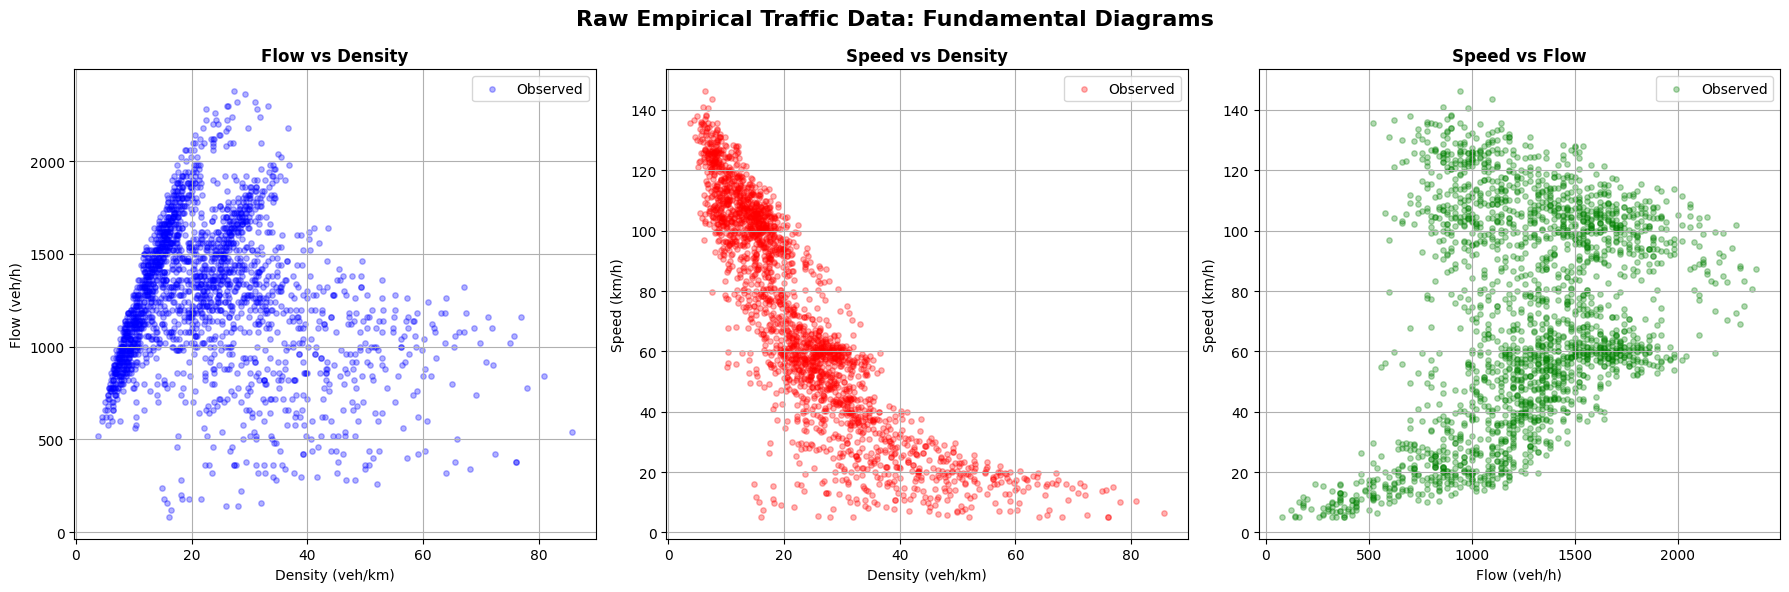

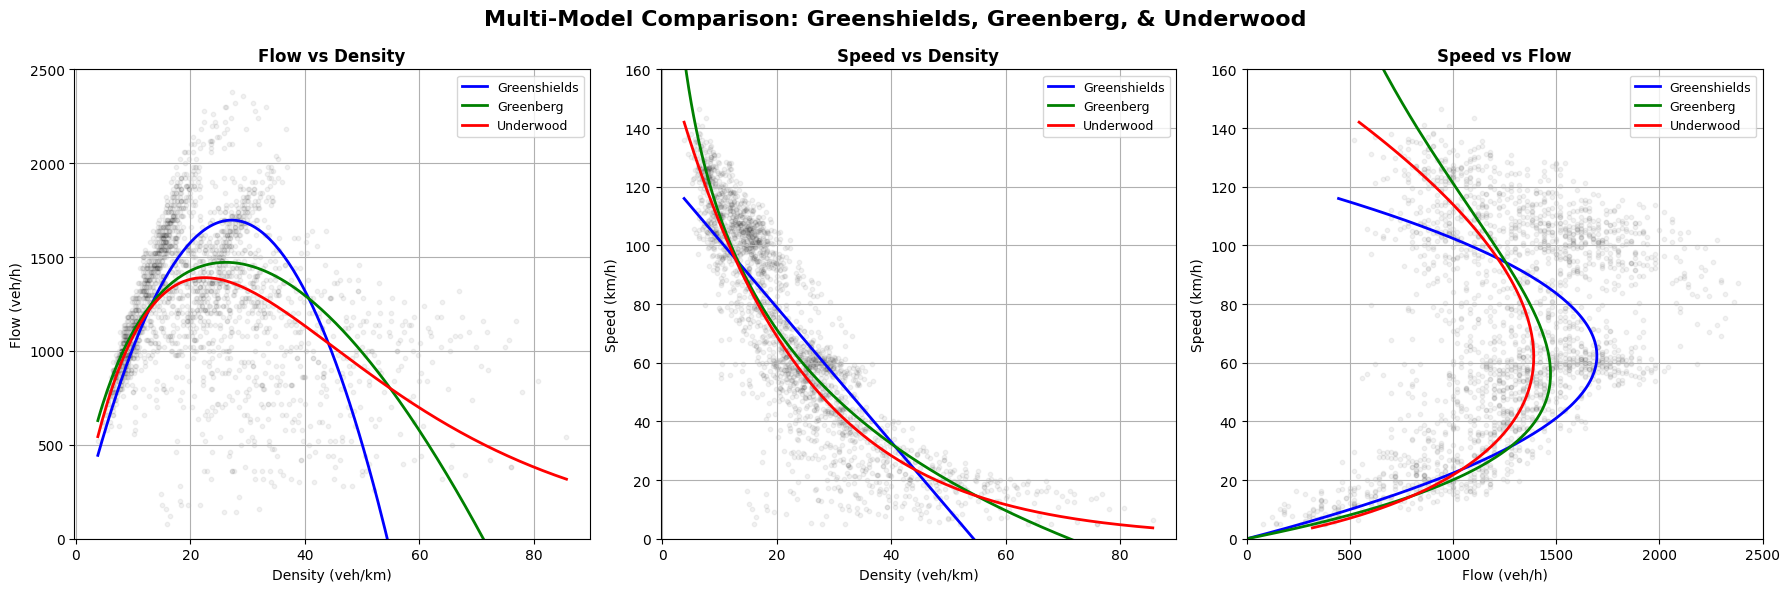

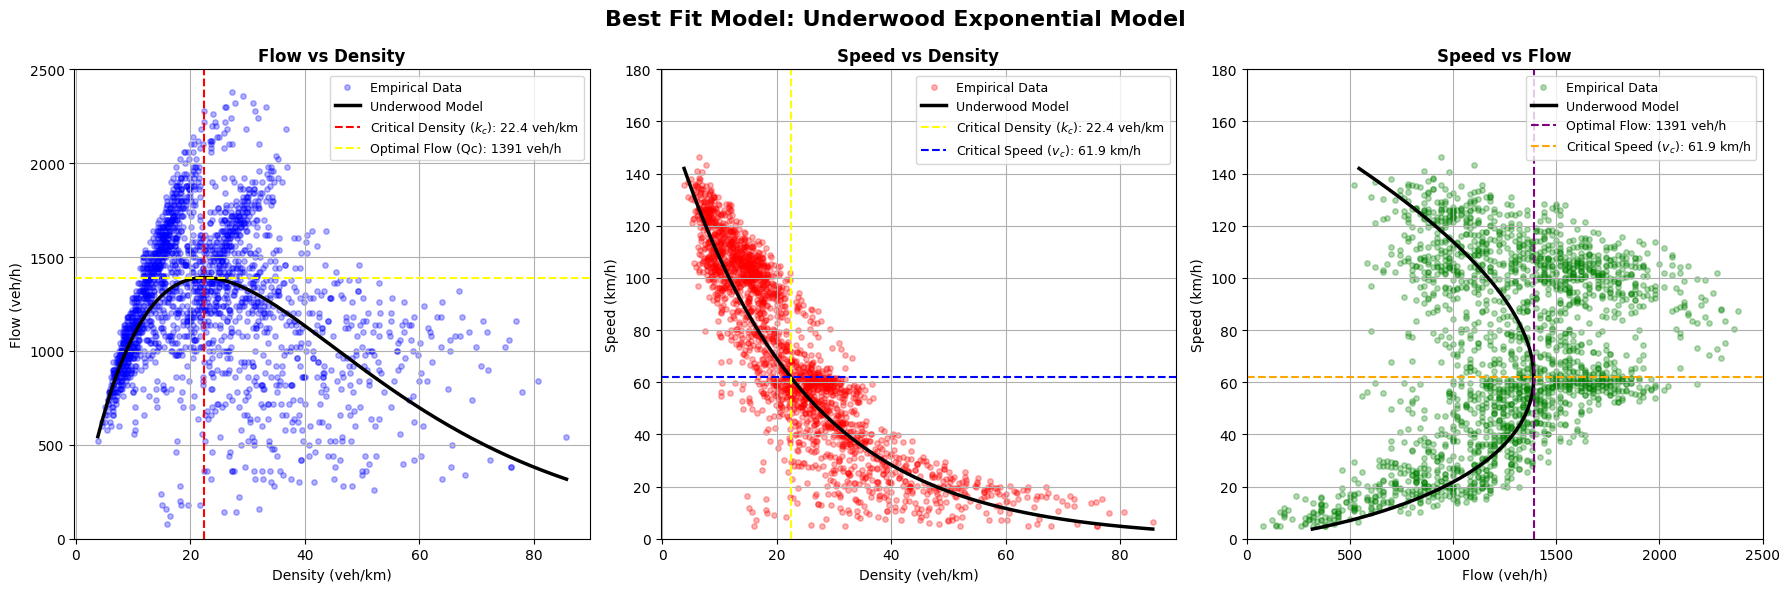

In [9]:
# Create x-axis arrays for plotting smooth lines
k_vals = np.linspace(min(k), max(k), 200)

# PLOT SET 1: Raw Empirical Data
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 6))

axes1[0].scatter(k, q, alpha=0.3, s=15, color='blue')
axes1[0].set_title('Flow vs Density', fontweight='bold')

axes1[1].scatter(k, v, alpha=0.3, s=15, color='red')
axes1[1].set_title('Speed vs Density', fontweight='bold')

axes1[2].scatter(q, v, alpha=0.3, s=15, color='green')
axes1[2].set_title('Speed vs Flow', fontweight='bold')

# Formatting for Plot 1
axes1[0].set_xlabel('Density (veh/km)'); axes1[0].set_ylabel('Flow (veh/h)'); axes1[0].grid(True) 
axes1[0].legend(['Observed'])
axes1[1].set_xlabel('Density (veh/km)'); axes1[1].set_ylabel('Speed (km/h)'); axes1[1].grid(True) 
axes1[1].legend(['Observed'])
axes1[2].set_xlabel('Flow (veh/h)'); axes1[2].set_ylabel('Speed (km/h)'); axes1[2].grid(True) 
axes1[2].legend(['Observed'])

fig1.suptitle('Raw Empirical Traffic Data: Fundamental Diagrams', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("Fundamental_diagram.png", dpi=300)
plt.show()

# PLOT SET 2: Multi-Model Comparison
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6))

colors = ['blue', 'green', 'red']
labels = ['Greenshields', 'Greenberg', 'Underwood']
v_plots_k = [v_f_g * (1 - k_vals/k_j_g), c_val * np.log(k_j_gb/k_vals), v_f_u * np.exp(-k_vals/k_m_u)]

# Background scatter points
axes2[0].scatter(k, q, alpha=0.05, color='black', s=10)
axes2[1].scatter(k, v, alpha=0.05, color='black', s=10)
axes2[2].scatter(q, v, alpha=0.05, color='black', s=10)

for i, v_plot in enumerate(v_plots_k):
    axes2[0].plot(k_vals, k_vals * v_plot, label=labels[i], color=colors[i], lw=2)
    axes2[1].plot(k_vals, v_plot, label=labels[i], color=colors[i], lw=2)
    axes2[2].plot(k_vals * v_plot, v_plot, label=labels[i], color=colors[i], lw=2)

axes2[0].set_ylim(0, 2500); axes2[1].set_ylim(0, 160); axes2[2].set_xlim(0, 2500); axes2[2].set_ylim(0, 160)
axes2[0].set_title('Flow vs Density', fontweight='bold')
axes2[1].set_title('Speed vs Density', fontweight='bold')
axes2[2].set_title('Speed vs Flow', fontweight='bold')

# Formatting for Plot 2
axes2[0].set_xlabel('Density (veh/km)'); axes2[0].set_ylabel('Flow (veh/h)'); axes2[0].grid(True); axes2[0].legend(fontsize=9)
axes2[1].set_xlabel('Density (veh/km)'); axes2[1].set_ylabel('Speed (km/h)'); axes2[1].grid(True); axes2[1].legend(fontsize=9)
axes2[2].set_xlabel('Flow (veh/h)');     axes2[2].set_ylabel('Speed (km/h)'); axes2[2].grid(True); axes2[2].legend(fontsize=9)

fig2.suptitle('Multi-Model Comparison: Greenshields, Greenberg, & Underwood', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("Multi_Model_Comparison.png", dpi=300)
plt.show()

# PLOT SET 3: Best Model (Underwood)
fig3, axes3 = plt.subplots(1, 3, figsize=(18, 6))

v_u_plot_k = v_f_u * np.exp(-k_vals / k_m_u)

axes3[0].scatter(k, q, alpha=0.3, s=15, color='blue', label='Empirical Data')
axes3[0].plot(k_vals, k_vals * v_u_plot_k, color='black', lw=2.5, label='Underwood Model')
axes3[0].axvline(k_m_u, color='red', linestyle='--', label=f'Critical Density ($k_c$): {k_m_u:.1f} veh/km')
axes3[0].axhline(q_c_u, color='yellow', linestyle='--', label=f'Optimal Flow (Qc): {q_c_u:.0f} veh/h')
axes3[0].set_title('Flow vs Density', fontweight='bold')
axes3[0].set_ylim(0, 2500)

axes3[1].scatter(k, v, alpha=0.3, s=15, color='red', label='Empirical Data')
axes3[1].plot(k_vals, v_u_plot_k, color='black', lw=2.5, label='Underwood Model')
axes3[1].axvline(k_m_u, color='yellow', linestyle='--', label=f'Critical Density ($k_c$): {k_m_u:.1f} veh/km')
axes3[1].axhline(v_c_u, color='blue', linestyle='--', label=f'Critical Speed ($v_c$): {v_c_u:.1f} km/h')
axes3[1].set_title('Speed vs Density', fontweight='bold')
axes3[1].set_ylim(0, 180)

axes3[2].scatter(q, v, alpha=0.3, s=15, color='green', label='Empirical Data')
axes3[2].plot(k_vals * v_u_plot_k, v_u_plot_k, color='black', lw=2.5, label='Underwood Model')
axes3[2].axvline(q_c_u, color='purple', linestyle='--', label=f'Optimal Flow: {q_c_u:.0f} veh/h')
axes3[2].axhline(v_c_u, color='orange', linestyle='--', label=f'Critical Speed ($v_c$): {v_c_u:.1f} km/h')
axes3[2].set_title('Speed vs Flow', fontweight='bold')
axes3[2].set_xlim(0, 2500); axes3[2].set_ylim(0, 180)

# Formatting for Plot 3
axes3[0].set_xlabel('Density (veh/km)'); axes3[0].set_ylabel('Flow (veh/h)'); axes3[0].grid(True); axes3[0].legend(fontsize=9)
axes3[1].set_xlabel('Density (veh/km)'); axes3[1].set_ylabel('Speed (km/h)'); axes3[1].grid(True); axes3[1].legend(fontsize=9)
axes3[2].set_xlabel('Flow (veh/h)');     axes3[2].set_ylabel('Speed (km/h)'); axes3[2].grid(True); axes3[2].legend(fontsize=9)

fig3.suptitle('Best Fit Model: Underwood Exponential Model', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("Underwood.png", dpi=300)
plt.show()